In [87]:
from sklearn.model_selection import train_test_split
import pandas as pd
import numpy as np
from assignments.helpers import preprocess_data
from sklearn.impute import SimpleImputer
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import OrdinalEncoder
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LinearRegression
from sklearn.linear_model import SGDRegressor
from sklearn.metrics import mean_absolute_error, root_mean_squared_error, r2_score

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

from sklearn.preprocessing import PolynomialFeatures
from sklearn.model_selection import GridSearchCV, KFold

In [88]:
preprocessed_data = preprocess_data()
preprocessed_data.shape

(1460, 20)

In [89]:
preprocessed_data.head()

,LotArea,LotConfig,Neighborhood,BldgType,OverallQual,YearBuilt,MasVnrArea,BsmtExposure,BsmtFinType1,TotalBsmtSF,HeatingQC,CentralAir,GrLivArea,FullBath,Fireplaces,FireplaceQu,GarageFinish,GarageCars,SaleCondition,SalePrice
0,8450,Inside,CollgCr,1Fam,7,2003,196.0,No,GLQ,856,Ex,Y,1710,2,0,NaN,RFn,2,Normal,208500
1,9600,FR2,Veenker,1Fam,6,1976,0.0,Gd,ALQ,1262,Ex,Y,1262,2,1,TA,RFn,2,Normal,181500
2,11250,Inside,CollgCr,1Fam,7,2001,162.0,Mn,GLQ,920,Ex,Y,1786,2,1,TA,RFn,2,Normal,223500
3,9550,Corner,Crawfor,1Fam,7,1915,0.0,No,ALQ,756,Gd,Y,1717,1,1,Gd,Unf,3,Abnorml,140000
4,14260,FR2,NoRidge,1Fam,8,2000,350.0,Av,GLQ,1145,Ex,Y,2198,2,1,TA,RFn,3,Normal,250000


In [90]:
# Dropping the single record with a genuinely missing BsmtExposure (basement exists, value missing)
genuine_missing = preprocessed_data["BsmtExposure"].isnull() & (preprocessed_data["TotalBsmtSF"] > 0)
print("Rows dropped:", genuine_missing.sum())
preprocessed_data = preprocessed_data[~genuine_missing].copy()
print(preprocessed_data.shape)

Rows dropped: 1
(1459, 20)


In [91]:
# Drop the two known anomalous records: very large, top-quality houses with implausibly low prices
anomalous = (preprocessed_data["GrLivArea"] > 4000) & (preprocessed_data["SalePrice"] < 300000)
print("Rows dropped:", anomalous.sum())          # expected: 2
preprocessed_data = preprocessed_data[~anomalous].copy()
print(preprocessed_data.shape)                    # expected: (1457, 20)

Rows dropped: 2
(1457, 20)


In [92]:
# Drop extreme LotArea records (huge lots with ordinary prices, no matching price signal)
extreme_lot = preprocessed_data["LotArea"] > 100000
print("Rows dropped:", extreme_lot.sum())          # expected: 4
preprocessed_data = preprocessed_data[~extreme_lot].copy()
print(preprocessed_data.shape)                      # expected: (1453, 20)

Rows dropped: 4
(1453, 20)


In [93]:
price_bins = pd.qcut(preprocessed_data["SalePrice"], q=5, labels=False)

In [94]:
train_data, test_data = train_test_split(
    preprocessed_data,
    test_size=0.25,
    random_state=42,
    stratify=price_bins
)

In [95]:
# let's find the shape of our datasets
print(train_data.shape)
print(test_data.shape) 

(1089, 20)
(364, 20)


In [96]:
# Column groups
median_impute_col = ["MasVnrArea"]
none_impute_ordinal_cols = ["BsmtExposure", "BsmtFinType1", "FireplaceQu", "GarageFinish"]
ordinal_only_col = ["HeatingQC"]
passthrough_cols = ["LotArea", "OverallQual", "YearBuilt", "TotalBsmtSF",
                     "GrLivArea", "FullBath", "Fireplaces", "GarageCars"]
nominal_cols = ["Neighborhood", "CentralAir", "LotConfig", "BldgType", "SaleCondition"]


In [97]:
# Category orders, these lists show the ordinal categories, add 'None' for missing features to make a new category
none_impute_ordinal_orders = [
    ["None", "No", "Mn", "Av", "Gd"],                    # BsmtExposure
    ["None", "Unf", "LwQ", "Rec", "BLQ", "ALQ", "GLQ"],  # BsmtFinType1
    ["None", "Po", "Fa", "TA", "Gd", "Ex"],              # FireplaceQu
    ["None", "Unf", "RFn", "Fin"],                       # GarageFinish
]
heatingqc_order = [["Po", "Fa", "TA", "Gd", "Ex"]]

In [98]:
# Sub-pipelines
median_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median"))
])

none_ordinal_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="constant", fill_value="None")),
    ("encoder", OrdinalEncoder(categories=none_impute_ordinal_orders))
])

heatingqc_pipeline = Pipeline([
    ("encoder", OrdinalEncoder(categories=heatingqc_order))
])

onehot_pipeline = Pipeline([
    ("encoder", OneHotEncoder(drop="first", sparse_output=False))
])


In [99]:
# ColumnTransformer combines all of the sub-pipelines
preprocessor = ColumnTransformer([
    ("median_impute", median_pipeline, median_impute_col),
    ("none_ordinal", none_ordinal_pipeline, none_impute_ordinal_cols),
    ("heatingqc", heatingqc_pipeline, ordinal_only_col),
    ("passthrough", "passthrough", passthrough_cols),
    ("onehot", onehot_pipeline, nominal_cols),
])

In [100]:
full_pipeline = Pipeline([
    ("preprocessing", preprocessor),
    ("scaling", StandardScaler())
])

In [101]:
X_train_raw = train_data.drop(columns=["SalePrice"])
y_train = train_data["SalePrice"]
X_test_raw = test_data.drop(columns=["SalePrice"])
y_test = test_data["SalePrice"]

In [102]:
X_train_unscaled = full_pipeline.named_steps["preprocessing"].fit_transform(X_train_raw)
X_test_unscaled = full_pipeline.named_steps["preprocessing"].transform(X_test_raw)

In [103]:
type(X_train_unscaled)

numpy.ndarray

### **Step 1: Generating Polynomial Features**

Polynomial features are generated **only from the 8 continuous numerical predictors** 
1. `LotArea` 
2. `YearBuilt`
3. `MasVnrArea`
4. `TotalBsmtSF`
5. `GrLivArea`
6. `FullBath`
7. `Fireplaces`
8. `GarageCars`

**Why this approach:** squaring or multiplying dummy variables (0/1) is mathematically uninformative.
**Squaring** a binary value returns the same value like, `dummy² = dummy`.
Multiplying two different one-hot dummies from the same categorical is always 0.
Including these would inflate the feature count substantially without genuine new features.

**Polynomial model** focuses on the continuous features, where non-linear and interaction become literally meaningful.

In [63]:
feature_names = full_pipeline.named_steps["preprocessing"].get_feature_names_out()

continuous_cols = ["LotArea", "YearBuilt", "MasVnrArea", "TotalBsmtSF",
                    "GrLivArea", "FullBath", "Fireplaces", "GarageCars"]

continuous_indices = [i for i, name in enumerate(feature_names)
                       if name.split("__")[-1] in continuous_cols]

X_train_continuous = X_train_unscaled[:, continuous_indices]
X_test_continuous = X_test_unscaled[:, continuous_indices]

print("Selected features:", [feature_names[i] for i in continuous_indices])
print("X_train_continuous shape:", X_train_continuous.shape)
print("X_test_continuous shape:", X_test_continuous.shape)

Selected features: ['median_impute__MasVnrArea', 'passthrough__LotArea', 'passthrough__YearBuilt', 'passthrough__TotalBsmtSF', 'passthrough__GrLivArea', 'passthrough__FullBath', 'passthrough__Fireplaces', 'passthrough__GarageCars']
X_train_continuous shape: (1089, 8)
X_test_continuous shape: (364, 8)


In [64]:
X_train_continuous[:1,:]

array([[0.000e+00, 7.711e+03, 1.977e+03, 1.440e+03, 1.440e+03, 2.000e+00,
        0.000e+00, 0.000e+00]])

In [65]:
X_train_continuous

array([[0.0000e+00, 7.7110e+03, 1.9770e+03, ..., 2.0000e+00, 0.0000e+00,
        0.0000e+00],
       [4.9100e+02, 1.0197e+04, 1.9610e+03, ..., 1.0000e+00, 1.0000e+00,
        2.0000e+00],
       [0.0000e+00, 1.0634e+04, 1.9530e+03, ..., 1.0000e+00, 0.0000e+00,
        1.0000e+00],
       ...,
       [0.0000e+00, 5.3300e+03, 1.9400e+03, ..., 1.0000e+00, 0.0000e+00,
        0.0000e+00],
       [0.0000e+00, 9.6380e+03, 1.9190e+03, ..., 2.0000e+00, 1.0000e+00,
        1.0000e+00],
       [6.6400e+02, 1.3688e+04, 2.0030e+03, ..., 2.0000e+00, 2.0000e+00,
        3.0000e+00]], shape=(1089, 8))

### **2. Report**

**1. Number of predictors:**

**2. Number of polynomial features generated at each degree:** 

**3. Examples of individual-power terms:**

**4. Examples of cross or interaction terms:**

### **3. Develop a polynomial regression model for each degree:**

In [66]:
for degree in [2, 3, 4]:
    poly = PolynomialFeatures(degree=degree, include_bias=False)
    poly.fit(X_train_continuous)
    print(f"Degree {degree}: {len(poly.get_feature_names_out())} features generated")

Degree 2: 44 features generated
Degree 3: 164 features generated
Degree 4: 494 features generated


In [67]:
poly.get_feature_names_out()

array(['x0', 'x1', 'x2', 'x3', 'x4', 'x5', 'x6', 'x7', 'x0^2', 'x0 x1',
       'x0 x2', 'x0 x3', 'x0 x4', 'x0 x5', 'x0 x6', 'x0 x7', 'x1^2',
       'x1 x2', 'x1 x3', 'x1 x4', 'x1 x5', 'x1 x6', 'x1 x7', 'x2^2',
       'x2 x3', 'x2 x4', 'x2 x5', 'x2 x6', 'x2 x7', 'x3^2', 'x3 x4',
       'x3 x5', 'x3 x6', 'x3 x7', 'x4^2', 'x4 x5', 'x4 x6', 'x4 x7',
       'x5^2', 'x5 x6', 'x5 x7', 'x6^2', 'x6 x7', 'x7^2', 'x0^3',
       'x0^2 x1', 'x0^2 x2', 'x0^2 x3', 'x0^2 x4', 'x0^2 x5', 'x0^2 x6',
       'x0^2 x7', 'x0 x1^2', 'x0 x1 x2', 'x0 x1 x3', 'x0 x1 x4',
       'x0 x1 x5', 'x0 x1 x6', 'x0 x1 x7', 'x0 x2^2', 'x0 x2 x3',
       'x0 x2 x4', 'x0 x2 x5', 'x0 x2 x6', 'x0 x2 x7', 'x0 x3^2',
       'x0 x3 x4', 'x0 x3 x5', 'x0 x3 x6', 'x0 x3 x7', 'x0 x4^2',
       'x0 x4 x5', 'x0 x4 x6', 'x0 x4 x7', 'x0 x5^2', 'x0 x5 x6',
       'x0 x5 x7', 'x0 x6^2', 'x0 x6 x7', 'x0 x7^2', 'x1^3', 'x1^2 x2',
       'x1^2 x3', 'x1^2 x4', 'x1^2 x5', 'x1^2 x6', 'x1^2 x7', 'x1 x2^2',
       'x1 x2 x3', 'x1 x2 x4', 'x1 x2 x

### **Step 5: Degree Selection via K-Fold Cross-Validation**

**Pipeline:** 

`PolynomialFeatures` → `StandardScaler` → `LinearRegression` is wrapped in `GridSearchCV`.

**Testing degrees:**

2, 3, and 4 

**k-fold cross-validation:**

`GridSearchCV` performs k-fold cross-validation (k=5). 

**What happens inside `GridSearchCV`**

`GridSearchCV` evaluates each candidate degree by the given criterion, that is **R2-Score**. It selects the degree with the best average cross-validation score.
To avoid data leakage problem, only training data has been used in this process.

**`Scaling` is applied after polynomial expansion:**

The interaction and power terms must be generated from the original, unscaled feature values, just to keep them mathematically meaningful.

In [68]:
poly_pipeline = Pipeline([
    ("poly_features", PolynomialFeatures(include_bias=False)),
    ("scaling", StandardScaler()),
    ("model", LinearRegression())
])

param_grid = {"poly_features__degree": [2, 3, 4]}

kfold = KFold(n_splits=5, shuffle=True, random_state=42)

grid_search = GridSearchCV(
    poly_pipeline,
    param_grid=param_grid,
    cv=kfold,
    scoring="r2",
    return_train_score=True,
    refit=True,
    verbose=1
)

grid_search.fit(X_train_continuous, y_train)

print("Best degree:", grid_search.best_params_)
print("Best CV R² score:", grid_search.best_score_)

Fitting 5 folds for each of 3 candidates, totalling 15 fits


Best degree: {'poly_features__degree': 2}
Best CV R² score: 0.8306907155300391


In [69]:
grid_search.__dir__()

['scoring',
 'estimator',
 'n_jobs',
 'refit',
 'cv',
 'verbose',
 'pre_dispatch',
 'error_score',
 'return_train_score',
 'param_grid',
 '_checked_cv_orig',
 'n_splits_',
 'multimetric_',
 'best_index_',
 'best_score_',
 'best_params_',
 'best_estimator_',
 'refit_time_',
 'scorer_',
 'cv_results_',
 '__module__',
 '__annotations__',
 '__doc__',
 '_parameter_constraints',
 '__init__',
 '_run_search',
 '__abstractmethods__',
 '_abc_impl',
 '__sklearn_tags__',
 'score',
 '_wrap_namespace_error',
 'predict',
 'n_features_in_',
 '_check_refit_for_multimetric',
 '_select_best_index',
 '_get_scorers',
 '_check_scorers_accept_sample_weight',
 '_check_input_parameters',
 '_get_routed_params_for_fit',
 'fit',
 '_format_results',
 'get_metadata_routing',
 '_sk_visual_block_',
 '__dict__',
 '__weakref__',
 '__new__',
 '__repr__',
 '__hash__',
 '__str__',
 '__getattribute__',
 '__setattr__',
 '__delattr__',
 '__lt__',
 '__le__',
 '__eq__',
 '__ne__',
 '__gt__',
 '__ge__',
 '__reduce_ex__',
 '__re

In [70]:
grid_search.cv_results_

{'mean_fit_time': array([0.04757972, 0.14495454, 0.17854543]),
 'std_fit_time': array([0.04330968, 0.08118118, 0.12539583]),
 'mean_score_time': array([0.00905242, 0.00774913, 0.00732145]),
 'std_score_time': array([0.00285072, 0.00230431, 0.00438525]),
 'param_poly_features__degree': masked_array(data=[2, 3, 4],
              mask=[False, False, False],
        fill_value=999999),
 'params': [{'poly_features__degree': 2},
  {'poly_features__degree': 3},
  {'poly_features__degree': 4}],
 'split0_test_score': array([  0.83738616,   0.76537031, -76.49624303]),
 'split1_test_score': array([ 7.99222639e-01,  3.32351529e-01, -3.46468273e+02]),
 'split2_test_score': array([  0.87010577,   0.82600882, -50.94558333]),
 'split3_test_score': array([   0.78896918,    0.71248684, -141.43092693]),
 'split4_test_score': array([  0.85776984,   0.74332287, -56.82583381]),
 'mean_test_score': array([   0.83069072,    0.67590808, -134.43337201]),
 'std_test_score': array([3.18200584e-02, 1.75754139e-01,

In [71]:
cv_results = pd.DataFrame(grid_search.cv_results_)
cv_results

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_poly_features__degree,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,...,mean_test_score,std_test_score,rank_test_score,split0_train_score,split1_train_score,split2_train_score,split3_train_score,split4_train_score,mean_train_score,std_train_score
0,0.047580,0.043310,0.009052,0.002851,2,{'poly_features__degree': 2},0.837386,0.799223,0.870106,0.788969,...,0.830691,0.031820,1,0.873762,0.874650,0.868067,0.880077,0.869596,0.873230,0.004220
1,0.144955,0.081181,0.007749,0.002304,3,{'poly_features__degree': 3},0.765370,0.332352,0.826009,0.712487,...,0.675908,0.175754,2,0.907976,0.912210,0.906508,0.915863,0.911656,0.910842,0.003309
2,0.178545,0.125396,0.007321,0.004385,4,{'poly_features__degree': 4},-76.496243,-346.468273,-50.945583,-141.430927,...,-134.433372,110.776908,3,0.950741,0.954958,0.951239,0.958274,0.950465,0.953135,0.003039


In [72]:
cv_results = pd.DataFrame(grid_search.cv_results_)

cv_results_summary = cv_results[[
    "param_poly_features__degree",
    "mean_train_score",
    "mean_test_score",
    "std_test_score"
]].rename(columns={
    "param_poly_features__degree": "Degree",
    "mean_train_score": "Mean Train R²",
    "mean_test_score": "Mean Validation R²",
    "std_test_score": "Std Validation R²"
})

cv_results_summary

,Degree,Mean Train R²,Mean Validation R²,Std Validation R²
0,2,0.873230,0.830691,0.031820
1,3,0.910842,0.675908,0.175754
2,4,0.953135,-134.433372,110.776908


### **6. Let's Test the best model**

For the selected model, report: 

1. Intercept 

2. Coefficients of all individual-power terms; 

3. Coefficients of all interaction terms; 

4. Training and test MAE 

5. Training and test RMSE 

6. Training and test R2

In [73]:
best_poly_model = grid_search.best_estimator_

poly_train_preds = best_poly_model.predict(X_train_continuous)
poly_test_preds = best_poly_model.predict(X_test_continuous)

print("Train R²:", r2_score(y_train, poly_train_preds))
print("Test R²:", r2_score(y_test, poly_test_preds))
print("Train MAE:", mean_absolute_error(y_train, poly_train_preds))
print("Test MAE:", mean_absolute_error(y_test, poly_test_preds))
print("Train RMSE:", root_mean_squared_error(y_train, poly_train_preds))
print("Test RMSE:", root_mean_squared_error(y_test, poly_test_preds))

Train R²: 0.870809085636175
Test R²: 0.8558328998271231
Train MAE: 19894.704675811292
Test MAE: 21314.34399851643
Train RMSE: 28022.828238709135
Test RMSE: 31614.770031719712


In [74]:
best_poly_model.named_steps

{'poly_features': PolynomialFeatures(include_bias=False),
 'scaling': StandardScaler(),
 'model': LinearRegression()}

In [75]:
best_poly_model.named_steps["poly_features"]

PolynomialFeatures(include_bias=False)

In [76]:
coef_terms_values = best_poly_model.named_steps["model"].coef_

In [77]:
coef_terms_names = best_poly_model.named_steps["poly_features"].get_feature_names_out()

In [78]:
coef_table = pd.DataFrame({
    "Term": coef_terms_names,
    "Coefficient": coef_terms_values
})

In [79]:
coef_table.head()

,Term,Coefficient
0,x0,-613219.749514
1,x1,-88111.938694
2,x2,-542356.107696
3,x3,-874148.308540
4,x4,116953.255075


### **7. Present appropriate visualizations, including:** 

1. Training and validation error against polynomial degree 

2. Actual versus predicted values 

3. Residuals versus predicted values 

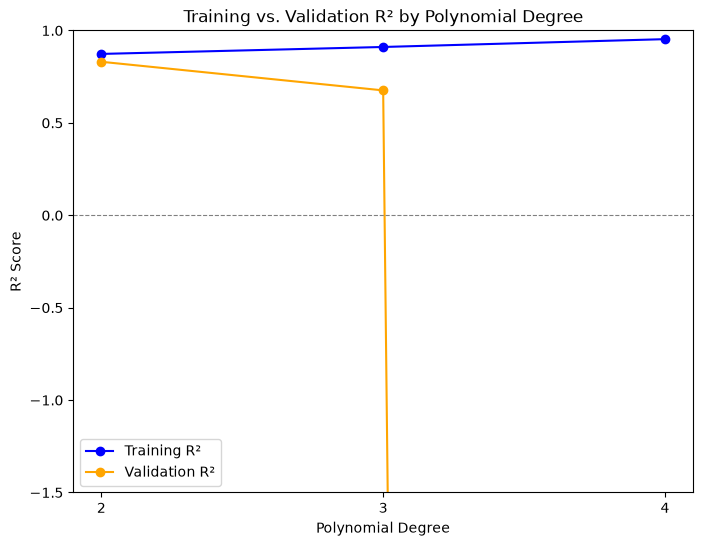

In [80]:
degrees = [2, 3, 4]
train_scores = cv_results_summary["Mean Train R²"].values
val_scores = cv_results_summary["Mean Validation R²"].values

fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(degrees, train_scores, marker="o", label="Training R²", color="blue")
ax.plot(degrees, val_scores, marker="o", label="Validation R²", color="orange")
ax.set_xticks(degrees)
ax.set_xlabel("Polynomial Degree")
ax.set_ylabel("R² Score")       
ax.set_title("Training vs. Validation R² by Polynomial Degree")
ax.set_ylim(-1.5, 1.0)
ax.axhline(0, color="gray", linestyle="--", linewidth=0.8)
ax.legend()
plt.show()

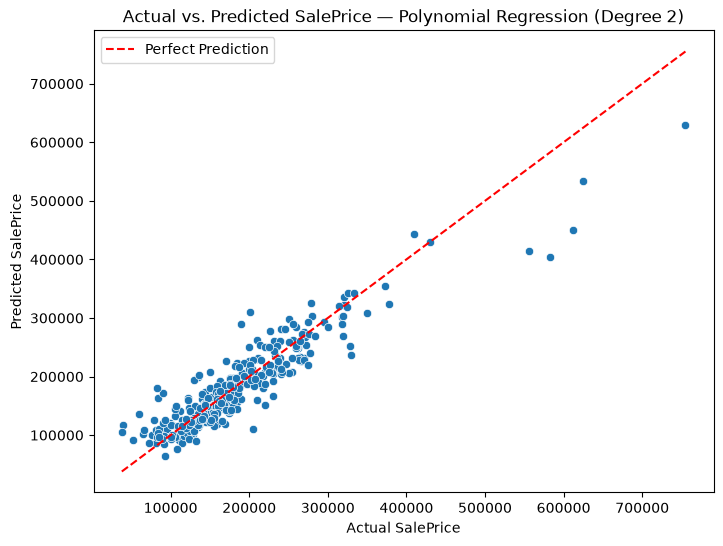

In [81]:
fig, ax = plt.subplots(figsize=(8, 6))
sns.scatterplot(x=y_test, y=poly_test_preds, ax=ax)
ax.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', label='Perfect Prediction')
ax.set_xlabel("Actual SalePrice")
ax.set_ylabel("Predicted SalePrice")
ax.set_title("Actual vs. Predicted SalePrice — Polynomial Regression (Degree 2)")
ax.legend()
plt.show()

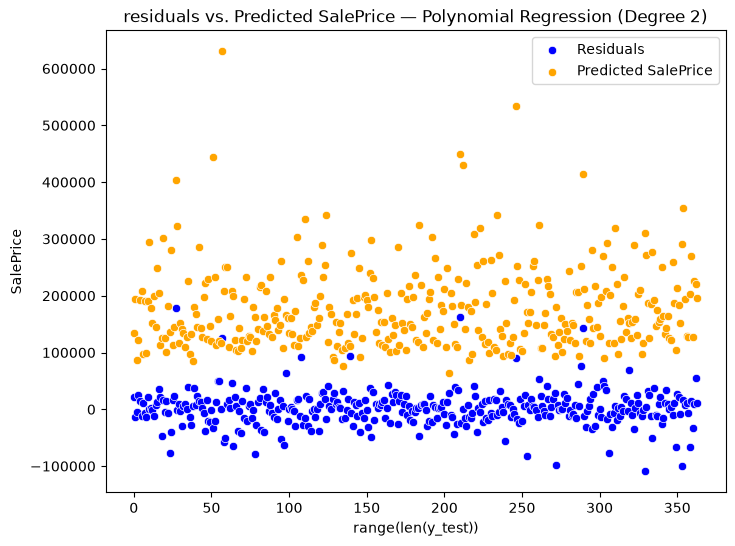

In [82]:
fig, ax = plt.subplots(figsize=(8, 6))
sns.scatterplot(x=range(len(y_test)), y=(y_test - poly_test_preds), ax=ax, label='Residuals', color='blue')
sns.scatterplot(x=range(len(y_test)), y=poly_test_preds, ax=ax, color='orange', label='Predicted SalePrice')
# ax.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', label='Perfect Prediction')
ax.set_xlabel("range(len(y_test))")
# ax.set_ylabel("residuals SalePrice")
ax.set_title("residuals vs. Predicted SalePrice — Polynomial Regression (Degree 2)")
ax.legend()
plt.show()

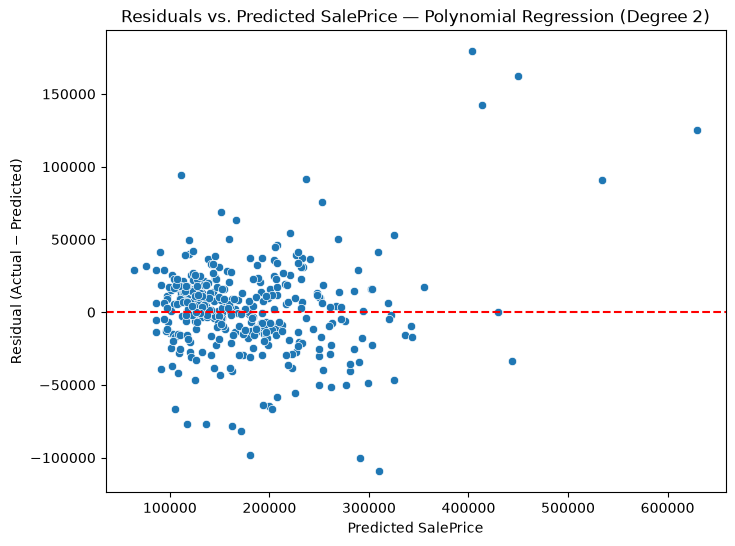

In [83]:
fig, ax = plt.subplots(figsize=(8, 6))
sns.scatterplot(x=poly_test_preds, y=y_test - poly_test_preds, ax=ax)
ax.axhline(0, color="red", linestyle="--")
ax.set_xlabel("Predicted SalePrice")
ax.set_ylabel("Residual (Actual − Predicted)")
ax.set_title("Residuals vs. Predicted SalePrice — Polynomial Regression (Degree 2)")
plt.show()

### **Compare the selected polynomial model with the multiple linear regression model from Q.1.**

In [84]:
# Q1 model on the same split and pipeline
X_train_q1 = full_pipeline.fit_transform(X_train_raw)
X_test_q1 = full_pipeline.transform(X_test_raw)
lin_model = LinearRegression().fit(X_train_q1, y_train)
lin_train, lin_test = lin_model.predict(X_train_q1), lin_model.predict(X_test_q1)

def metrics(y_tr, p_tr, y_te, p_te):
    return [r2_score(y_tr, p_tr), r2_score(y_te, p_te),
            mean_absolute_error(y_tr, p_tr), mean_absolute_error(y_te, p_te),
            root_mean_squared_error(y_tr, p_tr), root_mean_squared_error(y_te, p_te)]

comparison = pd.DataFrame({
    "Metric": ["Train R²", "Test R²", "Train MAE", "Test MAE", "Train RMSE", "Test RMSE"],
    "Linear (Q1)": metrics(y_train, lin_train, y_test, lin_test),
    "Polynomial (Q2)": metrics(y_train, poly_train_preds, y_test, poly_test_preds),
})
comparison["Difference (Poly − Linear)"] = comparison["Polynomial (Q2)"] - comparison["Linear (Q1)"]
comparison

,Metric,Linear (Q1),Polynomial (Q2),Difference (Poly − Linear)
0,Train R²,0.889319,0.870809,-0.018510
1,Test R²,0.851955,0.855833,0.003878
2,Train MAE,17987.927328,19894.704676,1906.777347
3,Test MAE,20082.502401,21314.343999,1231.841598
4,Train RMSE,25937.810519,28022.828239,2085.017719
5,Test RMSE,32037.122661,31614.770032,-422.352629


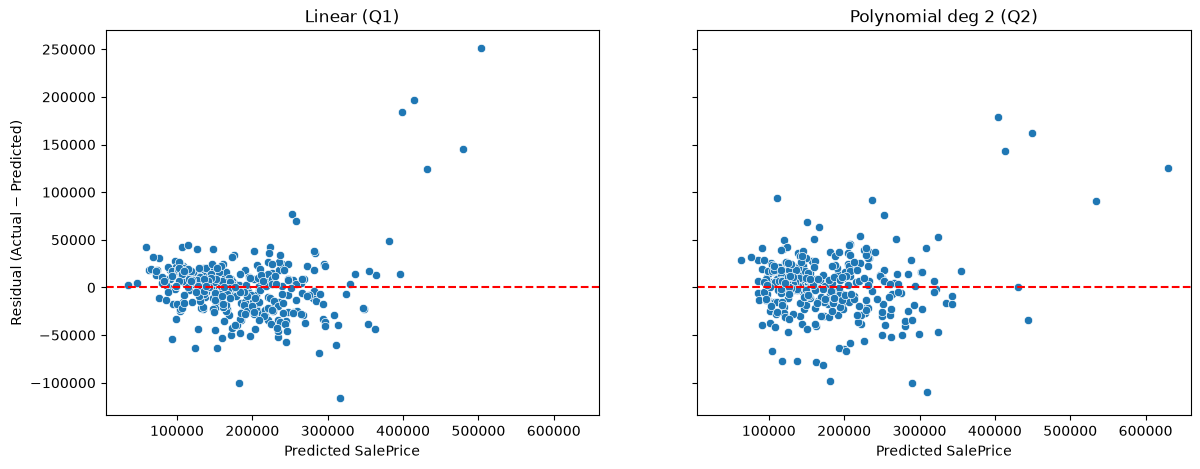

In [85]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True, sharex=True)
for ax, preds, title in zip(axes, [lin_test, poly_test_preds], ["Linear (Q1)", "Polynomial deg 2 (Q2)"]):
    sns.scatterplot(x=preds, y=y_test - preds, ax=ax)
    ax.axhline(0, color="red", linestyle="--")
    ax.set_title(title); ax.set_xlabel("Predicted SalePrice")
axes[0].set_ylabel("Residual (Actual − Predicted)")
plt.show()

### **9. Discuss:**

1. Whether polynomial regression improves generalization 
2. Evidence of underfitting or overfitting 
3. Growth in the number of generated features 
4. Multicollinearity among polynomial terms

In [86]:
selected_names = [feature_names[i].split("__")[-1] for i in continuous_indices]
print(selected_names)

poly2 = PolynomialFeatures(degree=2, include_bias=False)
X_train_poly2 = poly2.fit_transform(X_train_continuous)
poly2_df = pd.DataFrame(X_train_poly2, columns=poly2.get_feature_names_out(selected_names))

corr = poly2_df.corr()

# Strongest pairs, upper triangle only so each pair appears once
pairs = corr.where(np.triu(np.ones(corr.shape, dtype=bool), k=1)).stack()
pairs = pairs.reindex(pairs.abs().sort_values(ascending=False).index)

print("Pairs with |corr| > 0.9:", (pairs.abs() > 0.9).sum(), "of", len(pairs))
pairs.head(50)

['MasVnrArea', 'LotArea', 'YearBuilt', 'TotalBsmtSF', 'GrLivArea', 'FullBath', 'Fireplaces', 'GarageCars']
Pairs with |corr| > 0.9: 46 of 1936


YearBuilt               YearBuilt^2               0.999969
MasVnrArea              MasVnrArea YearBuilt      0.999947
Fireplaces              YearBuilt Fireplaces      0.999816
LotArea                 LotArea YearBuilt         0.999598
GarageCars              YearBuilt GarageCars      0.999475
TotalBsmtSF             YearBuilt TotalBsmtSF     0.999418
FullBath                YearBuilt FullBath        0.999184
GrLivArea               YearBuilt GrLivArea       0.998809
FullBath                FullBath^2                0.981943
YearBuilt FullBath      FullBath^2                0.980907
MasVnrArea GrLivArea    MasVnrArea FullBath       0.973961
GrLivArea               GrLivArea^2               0.972145
YearBuilt GrLivArea     GrLivArea^2               0.969218
MasVnrArea GrLivArea    MasVnrArea GarageCars     0.967314
MasVnrArea YearBuilt    MasVnrArea GarageCars     0.960692
                        MasVnrArea FullBath       0.960116
MasVnrArea              MasVnrArea GarageCars     0.9590

## **Let's run with all of the features:**

In [ ]:
# 8 continuous -> impute -> polynomial expansion
poly_cols = ["LotArea", "YearBuilt", "MasVnrArea", "TotalBsmtSF",
             "GrLivArea", "FullBath", "Fireplaces", "GarageCars"]

poly_branch = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("poly_features", PolynomialFeatures(include_bias=False))
])

# One-hot encoder that tolerates categories unseen in a CV training fold (e.g. Blueste)
onehot_pipeline_cv = Pipeline([
    ("encoder", OneHotEncoder(drop="first", sparse_output=False, handle_unknown="ignore"))
])

# 11 remaining features: reuse the Q1 sub-pipelines
full_preprocessor = ColumnTransformer([
    ("poly", poly_branch, poly_cols),
    ("none_ordinal", none_ordinal_pipeline, none_impute_ordinal_cols),
    ("heatingqc", heatingqc_pipeline, ordinal_only_col),
    ("overallqual", "passthrough", ["OverallQual"]),
    ("onehot", onehot_pipeline_cv, nominal_cols),
])

full_poly_pipeline = Pipeline([
    ("preprocessing", full_preprocessor),
    ("scaling", StandardScaler()),
    ("model", LinearRegression())
])

In [110]:
param_grid_full = {"preprocessing__poly__poly_features__degree": [2, 3, 4]}

grid_full = GridSearchCV(
    full_poly_pipeline,
    param_grid=param_grid_full,
    cv=KFold(n_splits=5, shuffle=True, random_state=42),
    scoring={"r2": "r2", "rmse": "neg_root_mean_squared_error"},
    refit="r2",
    return_train_score=True,
    n_jobs=-1,
    verbose=1
)
grid_full.fit(X_train_raw, y_train)   # raw DataFrame: imputation, encoding, scaling are refit inside each fold

print("Best degree:", grid_full.best_params_)
print("Best CV R²:", grid_full.best_score_)

res = pd.DataFrame(grid_full.cv_results_)
res_summary = pd.DataFrame({
    "Degree": [2, 3, 4],
    "Mean Train R²": res["mean_train_r2"],
    "Mean Val R²": res["mean_test_r2"],
    "Std Val R²": res["std_test_r2"],
    "Train RMSE": -res["mean_train_rmse"],
    "Val RMSE": -res["mean_test_rmse"],
})
res_summary

Fitting 5 folds for each of 3 candidates, totalling 15 fits
Best degree: {'preprocessing__poly__poly_features__degree': 2}
Best CV R²: 0.8971643647398932


,Degree,Mean Train R²,Mean Val R²,Std Val R²,Train RMSE,Val RMSE
0,2,0.934064,0.897164,0.012567,20009.673508,24742.116161
1,3,0.957320,0.764979,0.064385,16097.170579,36859.320138
2,4,0.985885,-128.843862,108.942526,9252.213254,796508.023341


In [106]:
print(train_data["Neighborhood"].value_counts().tail(5))
print(train_data["SaleCondition"].value_counts().tail(3))
print(train_data["BldgType"].value_counts().tail(3))

Neighborhood
MeadowV    12
BrDale     11
Veenker     8
NPkVill     6
Blueste     1
Name: count, dtype: int64
SaleCondition
Family     13
Alloca      9
AdjLand     2
Name: count, dtype: int64
BldgType
Duplex    39
Twnhs     30
2fmCon    21
Name: count, dtype: int64


## **Let's save the model for later use**

In [111]:
import joblib
best_full = grid_full.best_estimator_
joblib.dump(best_full, "house_price_model.joblib")

['house_price_model.joblib']

In [112]:
model = joblib.load("house_price_model.joblib")

new_house = pd.DataFrame([{
    "LotArea": 9600, "YearBuilt": 1995, "MasVnrArea": 0, "TotalBsmtSF": 1000,
    "GrLivArea": 1600, "FullBath": 2, "Fireplaces": 1, "GarageCars": 2,
    "OverallQual": 7,
    "BsmtExposure": "No", "BsmtFinType1": "GLQ", "FireplaceQu": "TA",
    "GarageFinish": "RFn", "HeatingQC": "Ex",
    "Neighborhood": "NAmes", "CentralAir": "Y", "LotConfig": "Inside",
    "BldgType": "1Fam", "SaleCondition": "Normal",
}])

predicted_price = model.predict(new_house)[0]

In [113]:
predicted_price

np.float64(206331.9690345834)